In [14]:
# Customer Churn Prediction for a Telecom Company
# Phase 9 – Hyperparameter Tuning

# Objective

# Optimize the best-performing machine learning models using hyperparameter tuning to improve predictive performance.

# Tasks

# - Load processed data
# - Tune Random Forest
# - Tune XGBoost
# - Tune LightGBM
# - Compare tuned models
# - Save tuned models
# - Save tuning results

In [15]:
import os
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from lightgbm import LGBMClassifier

from sklearn.metrics import accuracy_score

In [16]:
SAVE_PATH = "../images/07_Hyperparameter_Tuning"

os.makedirs(SAVE_PATH, exist_ok=True)

In [17]:
X_train = joblib.load("../data/processed/X_train.pkl")

X_test = joblib.load("../data/processed/X_test.pkl")

y_train = joblib.load("../data/processed/y_train.pkl")

y_test = joblib.load("../data/processed/y_test.pkl")

In [18]:
# Random Forest Grid Search

rf = RandomForestClassifier(random_state=42)

rf_params = {
    "n_estimators":[100,200,300],
    "max_depth":[5,10,20],
    "min_samples_split":[2,5,10]
}

rf_grid = GridSearchCV(
    rf,
    rf_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default

In [19]:
# Best Parameters

print(rf_grid.best_params_)

{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}


In [20]:
# Accuracy

rf_best = rf_grid.best_estimator_

y_pred = rf_best.predict(X_test)

print(accuracy_score(y_test,y_pred))

1.0


In [21]:
# Save Model

joblib.dump(
    rf_best,
    "../models/random_forest_tuned.pkl"
)

['../models/random_forest_tuned.pkl']

In [22]:
# Grid Search Results

rf_results = pd.DataFrame(
    rf_grid.cv_results_
)

rf_results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_split,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,1.267917,0.131860,0.049584,0.013612,5,2,100,"{'max_depth': 5, 'min_samples_split': 2, 'n_es...",1.0,1.0,1.0,1.0,1.0,1.0,0.0,1
1,1.784005,0.302056,0.077048,0.014241,5,2,200,"{'max_depth': 5, 'min_samples_split': 2, 'n_es...",1.0,1.0,1.0,1.0,1.0,1.0,0.0,1
2,2.924973,0.159119,0.119047,0.028023,5,2,300,"{'max_depth': 5, 'min_samples_split': 2, 'n_es...",1.0,1.0,1.0,1.0,1.0,1.0,0.0,1
3,1.189988,0.171937,0.061404,0.019007,5,5,100,"{'max_depth': 5, 'min_samples_split': 5, 'n_es...",1.0,1.0,1.0,1.0,1.0,1.0,0.0,1
4,1.650276,0.193935,0.127030,0.027087,5,5,200,"{'max_depth': 5, 'min_samples_split': 5, 'n_es...",1.0,1.0,1.0,1.0,1.0,1.0,0.0,1


In [23]:
# Save

rf_results.to_excel(
    "../reports/rf_gridsearch_results.xlsx",
    index=False
)

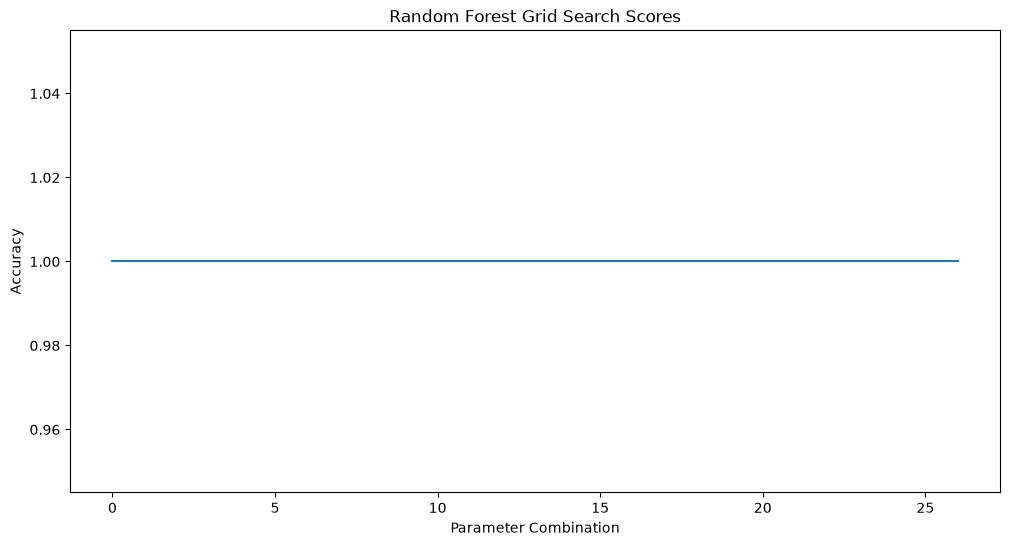

In [24]:
# Visualization

plt.figure(figsize=(12,6))

plt.plot(
    rf_results["mean_test_score"]
)

plt.title("Random Forest Grid Search Scores")

plt.xlabel("Parameter Combination")

plt.ylabel("Accuracy")

plt.savefig(
    os.path.join(
        SAVE_PATH,
        "RF_GridSearch_Scores.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

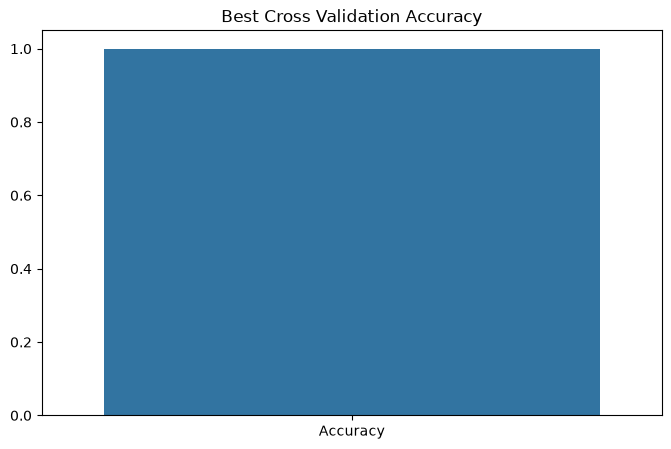

In [25]:
# Best Parameter Plot

plt.figure(figsize=(8,5))

sns.barplot(
    x=["Accuracy"],
    y=[rf_grid.best_score_]
)

plt.title("Best Cross Validation Accuracy")

plt.savefig(
    os.path.join(
        SAVE_PATH,
        "RF_Best_CV_Accuracy.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Best XGBoost params: {'colsample_bytree': np.float64(0.8123620356542087), 'gamma': np.float64(4.75357153204958), 'learning_rate': np.float64(0.22227824312530747), 'max_depth': 7, 'n_estimators': 120, 'reg_alpha': np.float64(0.15601864044243652), 'reg_lambda': np.float64(0.8119890406724053), 'subsample': np.float64(0.7174250836504598)}
Best XGBoost CV score: 1.0
XGBoost Tuned Test Accuracy: 1.0


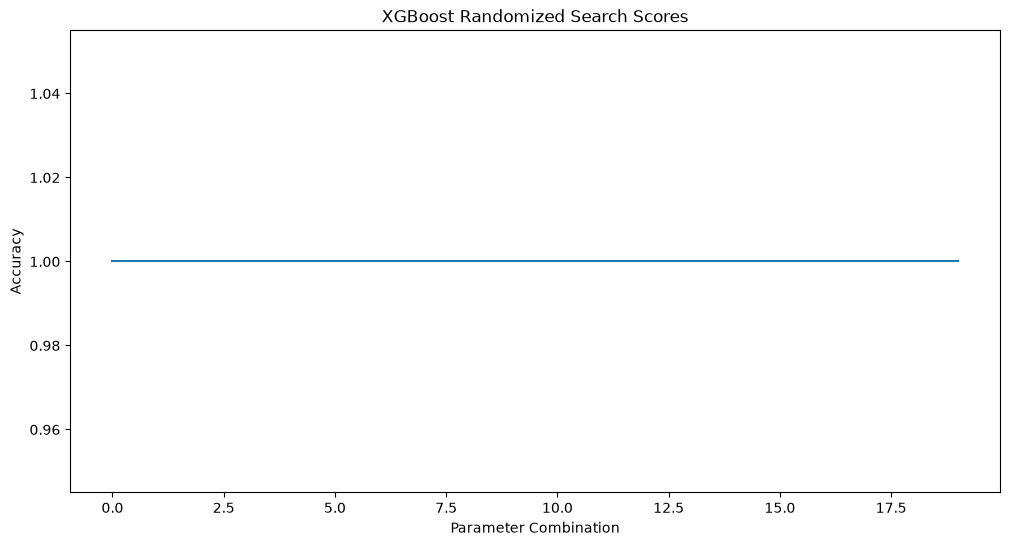

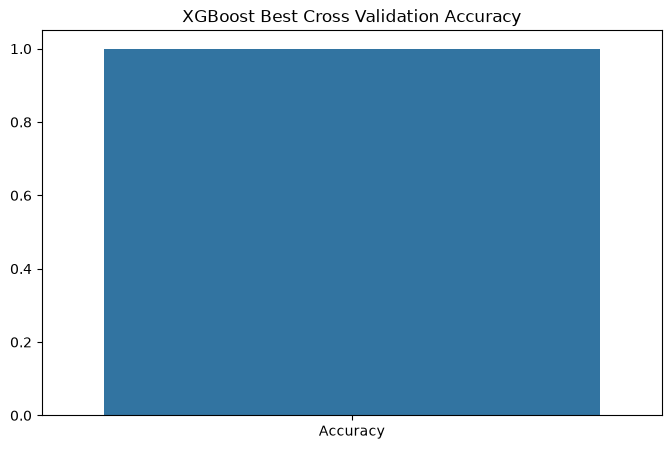

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000374 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 909
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

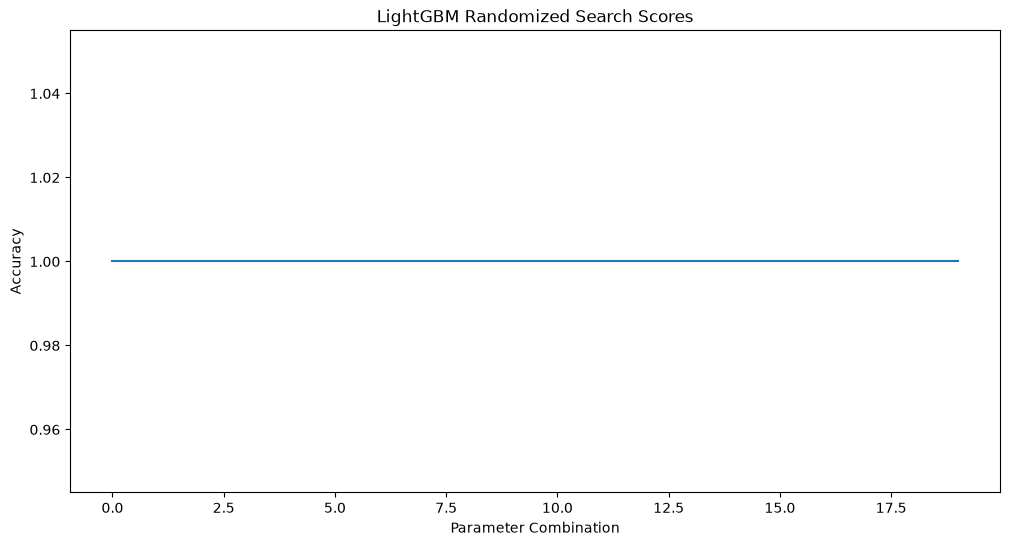

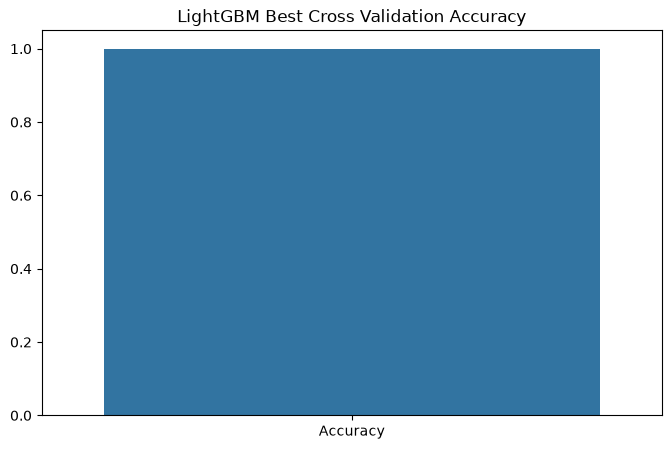

,Model,Tuned Accuracy,Best CV Accuracy
0,Random Forest,1.0,1.0
1,XGBoost,1.0,1.0
2,LightGBM,1.0,1.0


In [26]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# -----------------------
# XGBoost Randomized Search
# -----------------------
xgb = XGBClassifier(random_state=42, eval_metric="logloss")

xgb_params = {
    "n_estimators": randint(100, 500),
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.01, 0.29),
    "subsample": uniform(0.7, 0.3),
    "colsample_bytree": uniform(0.7, 0.3),
    "gamma": uniform(0, 5),
    "reg_alpha": uniform(0, 1),
    "reg_lambda": uniform(0.5, 2)
}

xgb_search = RandomizedSearchCV(
    xgb,
    xgb_params,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42
)

xgb_search.fit(X_train, y_train)

print("Best XGBoost params:", xgb_search.best_params_)
print("Best XGBoost CV score:", xgb_search.best_score_)

xgb_best = xgb_search.best_estimator_
xgb_pred = xgb_best.predict(X_test)
xgb_tuned_acc = accuracy_score(y_test, xgb_pred)

print("XGBoost Tuned Test Accuracy:", xgb_tuned_acc)

joblib.dump(xgb_best, "../models/xgboost_tuned.pkl")

xgb_results = pd.DataFrame(xgb_search.cv_results_)
xgb_results.to_excel("../reports/xgb_randomizedsearch_results.xlsx", index=False)

plt.figure(figsize=(12, 6))
plt.plot(xgb_results["mean_test_score"].values)
plt.title("XGBoost Randomized Search Scores")
plt.xlabel("Parameter Combination")
plt.ylabel("Accuracy")
plt.savefig(os.path.join(SAVE_PATH, "XGB_RandomizedSearch_Scores.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(x=["Accuracy"], y=[xgb_search.best_score_])
plt.title("XGBoost Best Cross Validation Accuracy")
plt.savefig(os.path.join(SAVE_PATH, "XGB_Best_CV_Accuracy.png"), dpi=300, bbox_inches="tight")
plt.show()

# -----------------------
# LightGBM Randomized Search
# -----------------------
lgbm = LGBMClassifier(random_state=42)

lgbm_params = {
    "n_estimators": randint(100, 500),
    "max_depth": randint(3, 12),
    "learning_rate": uniform(0.01, 0.29),
    "num_leaves": randint(20, 150),
    "subsample": uniform(0.7, 0.3),
    "colsample_bytree": uniform(0.7, 0.3),
    "reg_alpha": uniform(0, 1),
    "reg_lambda": uniform(0.5, 2)
}

lgbm_search = RandomizedSearchCV(
    lgbm,
    lgbm_params,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42
)

lgbm_search.fit(X_train, y_train)

print("Best LightGBM params:", lgbm_search.best_params_)
print("Best LightGBM CV score:", lgbm_search.best_score_)

lgbm_best = lgbm_search.best_estimator_
lgbm_pred = lgbm_best.predict(X_test)
lgbm_tuned_acc = accuracy_score(y_test, lgbm_pred)

print("LightGBM Tuned Test Accuracy:", lgbm_tuned_acc)

joblib.dump(lgbm_best, "../models/lightgbm_tuned.pkl")

lgbm_results = pd.DataFrame(lgbm_search.cv_results_)
lgbm_results.to_excel("../reports/lgbm_randomizedsearch_results.xlsx", index=False)

plt.figure(figsize=(12, 6))
plt.plot(lgbm_results["mean_test_score"].values)
plt.title("LightGBM Randomized Search Scores")
plt.xlabel("Parameter Combination")
plt.ylabel("Accuracy")
plt.savefig(os.path.join(SAVE_PATH, "LGBM_RandomizedSearch_Scores.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(x=["Accuracy"], y=[lgbm_search.best_score_])
plt.title("LightGBM Best Cross Validation Accuracy")
plt.savefig(os.path.join(SAVE_PATH, "LGBM_Best_CV_Accuracy.png"), dpi=300, bbox_inches="tight")
plt.show()

# -----------------------
# Final Comparison
# -----------------------
comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "LightGBM"],
    "Tuned Accuracy": [accuracy_score(y_test, rf_best.predict(X_test)), xgb_tuned_acc, lgbm_tuned_acc],
    "Best CV Accuracy": [rf_grid.best_score_, xgb_search.best_score_, lgbm_search.best_score_]
})

comparison.to_excel("../reports/Tuned_Model_Comparison.xlsx", index=False)
comparison